In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
# folder containing extracted CSV files
data_folder = "extracted_csv"

files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

datasets = {}

for file in files:
    
    path = os.path.join(data_folder, file)
    df = pd.read_csv(path)
    
    datasets[file] = df
    
    print(f"Loaded: {file}")

Loaded: Test_PD_CompleteS_1.2.csv
Loaded: Test_PD_CompleteS_2.2.csv
Loaded: Test_PD_CompleteS_3.2.csv
Loaded: Test_PD_CompleteS_4.2.csv
Loaded: Test_PD_CompleteS_5.2.csv
Loaded: Test_PD_Following_1.2.csv


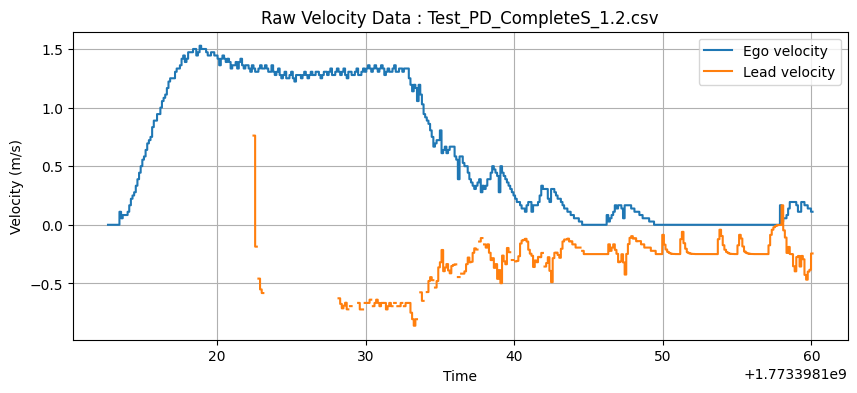

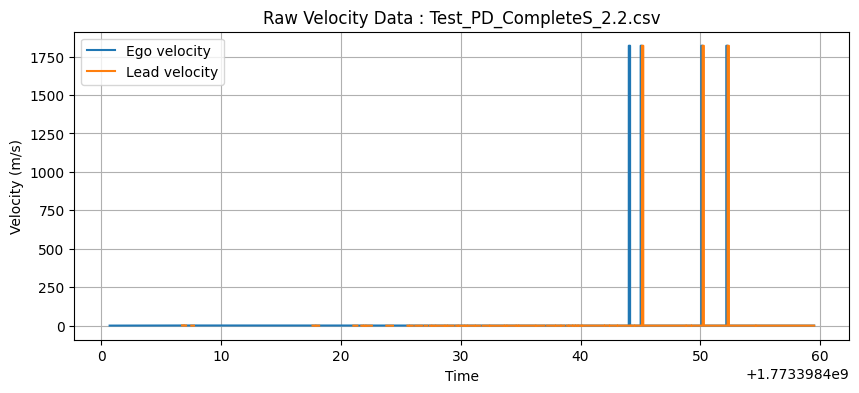

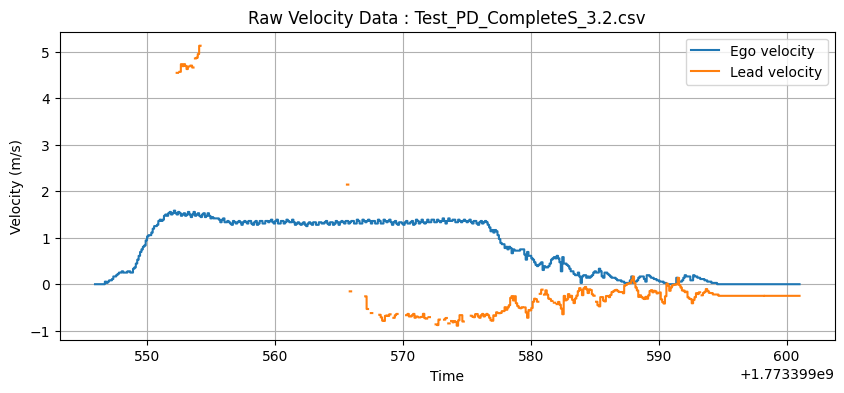

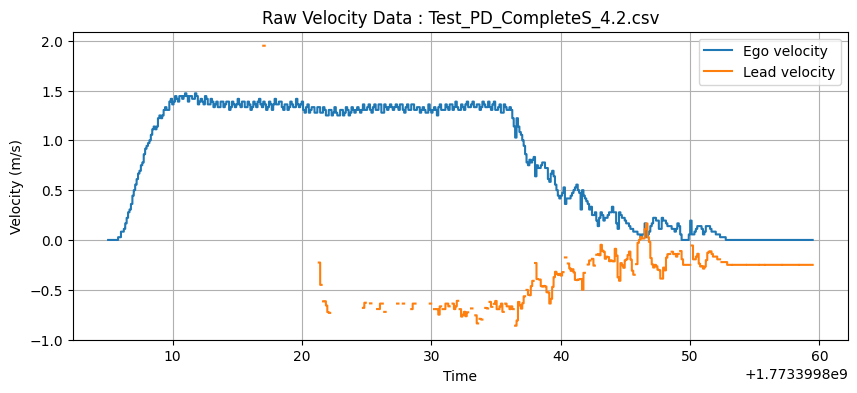

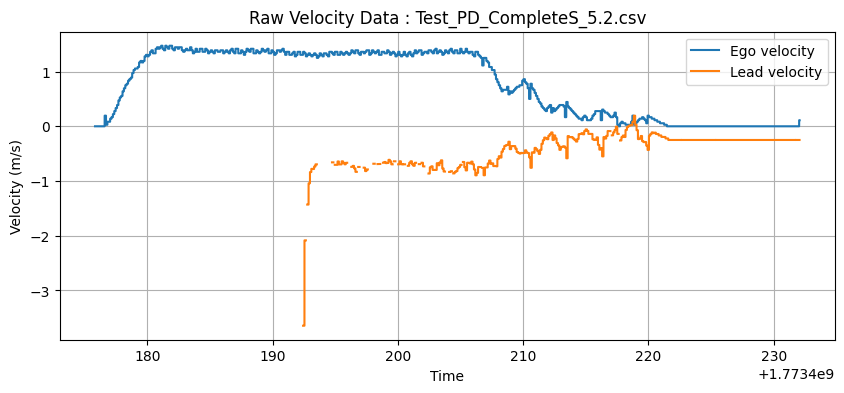

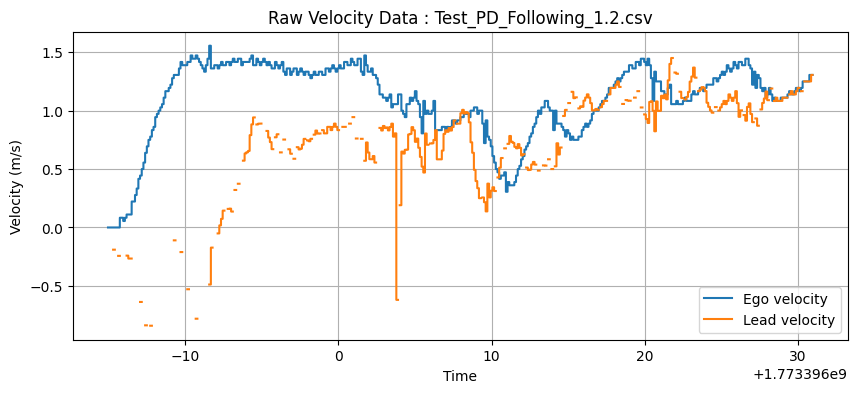

In [4]:
for name, df in datasets.items():
    
    time = df["ros_time"]
    
    plt.figure(figsize=(10,4))
    
    plt.plot(time, df["ego_velocity"], label="Ego velocity")
    
    if "lead_velocity" in df.columns:
        plt.plot(time, df["lead_velocity"], label="Lead velocity")
    
    plt.title(f"Raw Velocity Data : {name}")
    plt.xlabel("Time")
    plt.ylabel("Velocity (m/s)")
    plt.grid()
    plt.legend()
    
    plt.show()

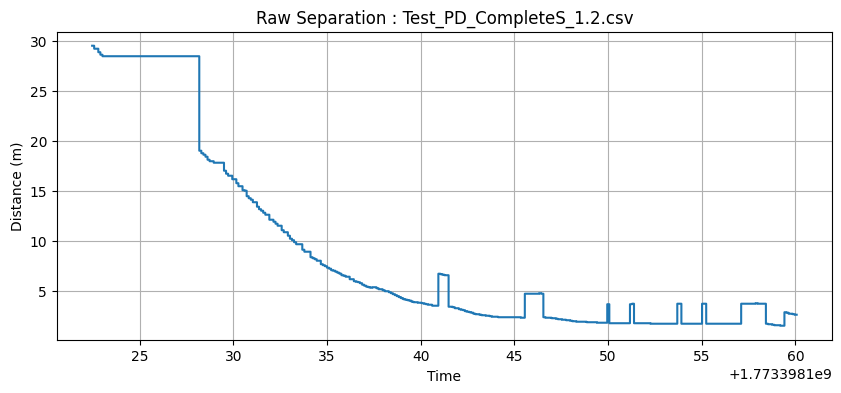

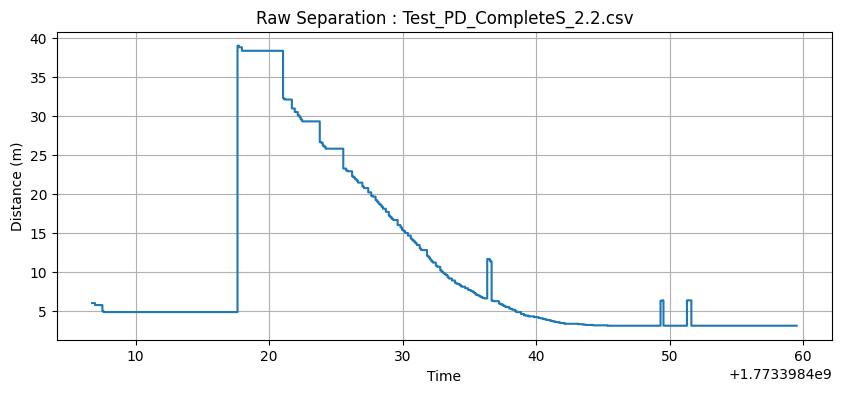

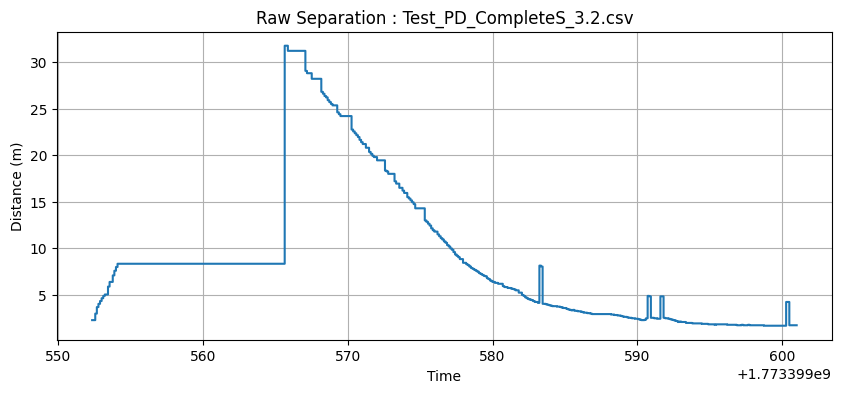

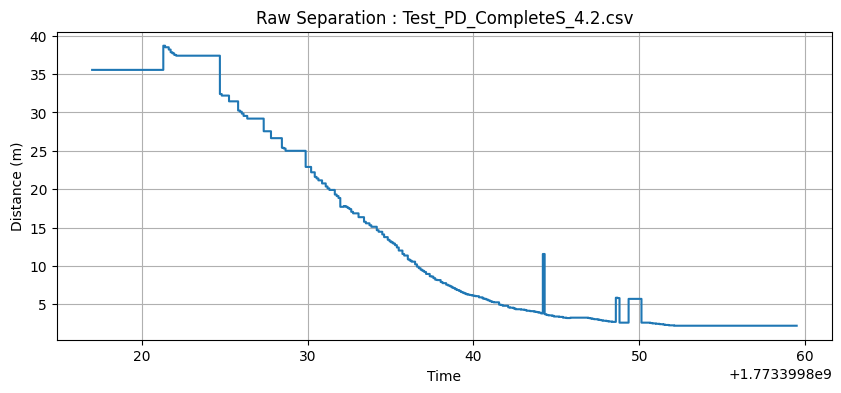

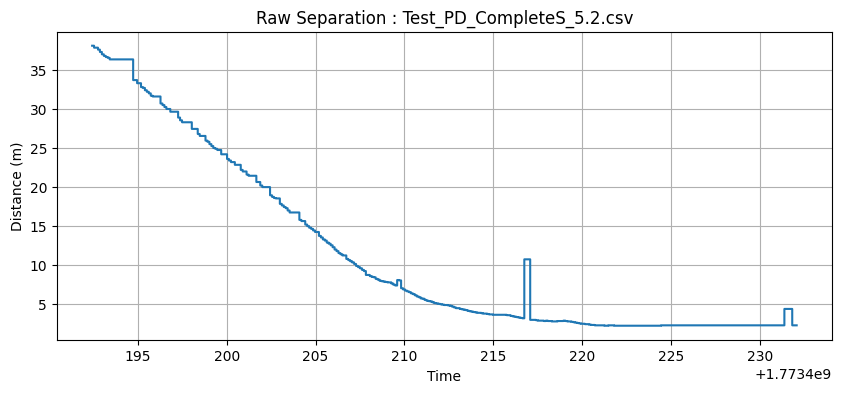

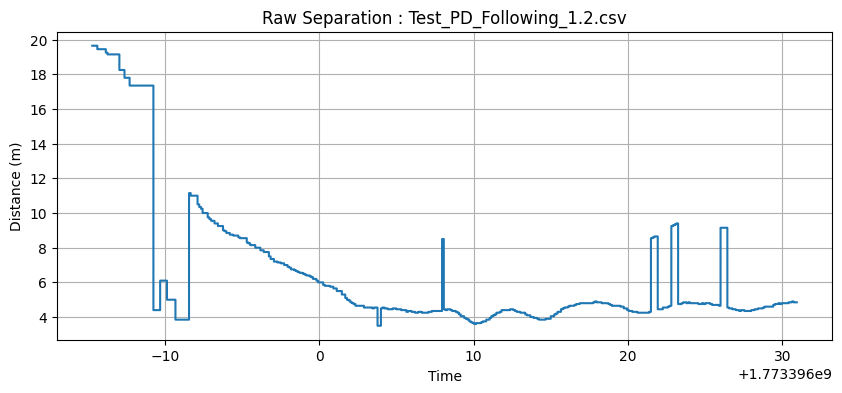

In [5]:
for name, df in datasets.items():
    
    if "separation" not in df.columns:
        continue
    
    plt.figure(figsize=(10,4))
    
    plt.plot(df["ros_time"], df["separation"])
    
    plt.title(f"Raw Separation : {name}")
    plt.xlabel("Time")
    plt.ylabel("Distance (m)")
    plt.grid()
    
    plt.show()

In [6]:
def remove_outliers(series, threshold=3):

    median = np.median(series)
    diff = np.abs(series - median)
    mad = np.median(diff)

    z_score = diff / (mad + 1e-6)

    series[z_score > threshold] = np.nan

    return series

In [7]:
cleaned_data = {}

for name, df in datasets.items():

    df_clean = df.copy()

    if "ego_velocity" in df.columns:
        df_clean["ego_velocity"] = remove_outliers(df_clean["ego_velocity"])

    if "separation" in df.columns:
        df_clean["separation"] = remove_outliers(df_clean["separation"])

    cleaned_data[name] = df_clean

C:\Users\home\AppData\Local\Temp\ipykernel_23096\3305164272.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[z_score > threshold] = np.nan
C:\Users\home\AppData\Local\Temp\ipykernel_23096\3305164272.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[z_score > threshold] = np.nan
C:\Users\home\AppData\Local\Temp\ipykernel_23096\3305164272.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[z_score > threshold] =

In [8]:
for name, df in cleaned_data.items():
    
    df.interpolate(method="linear", inplace=True)

In [9]:
for name, df in cleaned_data.items():

    if "ego_velocity" in df.columns:

        df["ego_velocity"] = signal.savgol_filter(
            df["ego_velocity"], 
            window_length=11, 
            polyorder=2
        )

    if "separation" in df.columns:

        df["separation"] = signal.savgol_filter(
            df["separation"], 
            window_length=11, 
            polyorder=2
        )

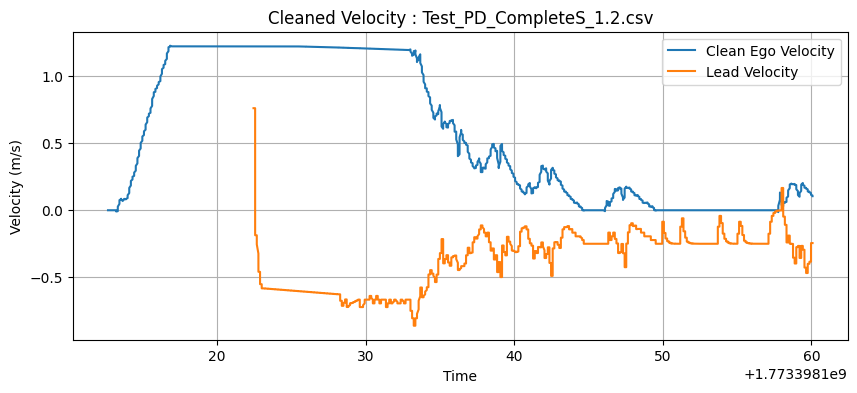

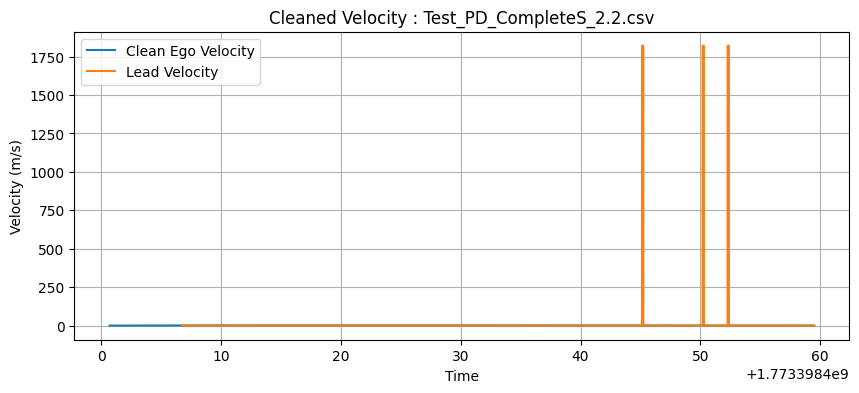

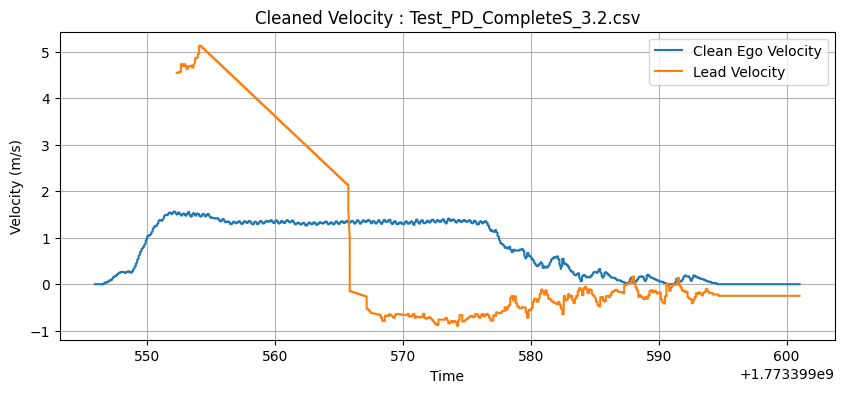

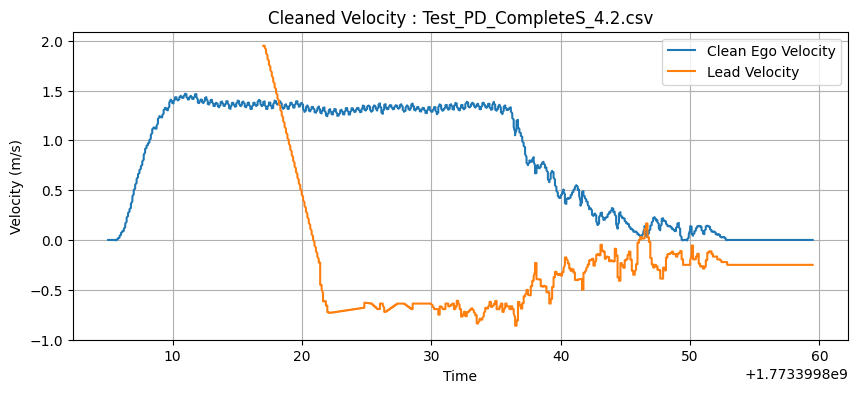

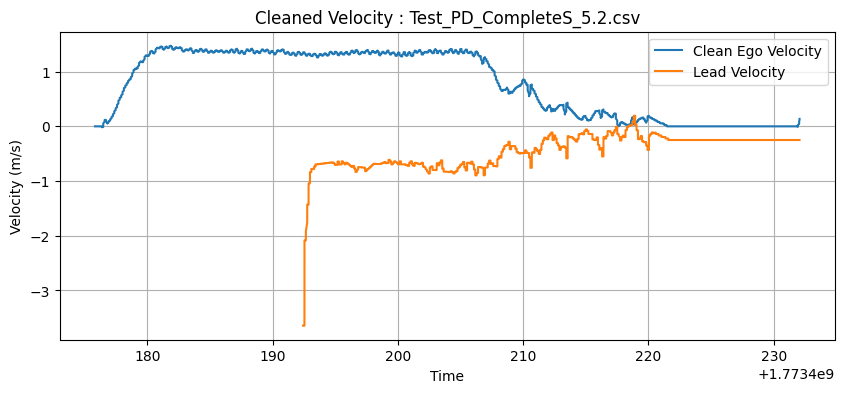

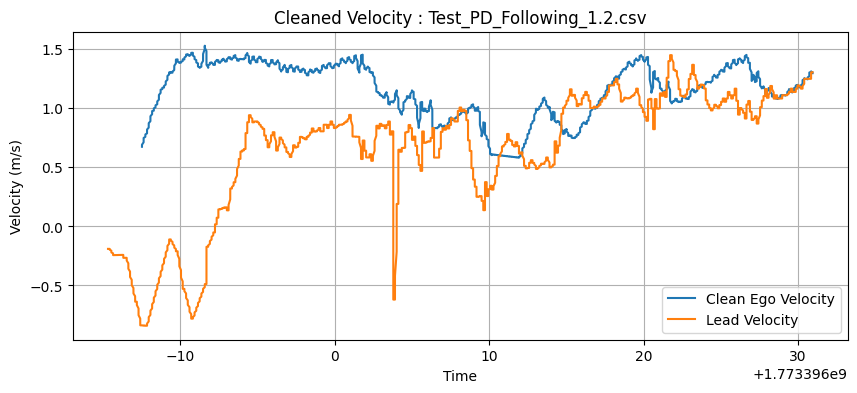

In [10]:
for name, df in cleaned_data.items():

    plt.figure(figsize=(10,4))

    plt.plot(df["ros_time"], df["ego_velocity"], label="Clean Ego Velocity")

    if "lead_velocity" in df.columns:
        plt.plot(df["ros_time"], df["lead_velocity"], label="Lead Velocity")

    plt.title(f"Cleaned Velocity : {name}")
    plt.xlabel("Time")
    plt.ylabel("Velocity (m/s)")
    plt.grid()
    plt.legend()

    plt.show()

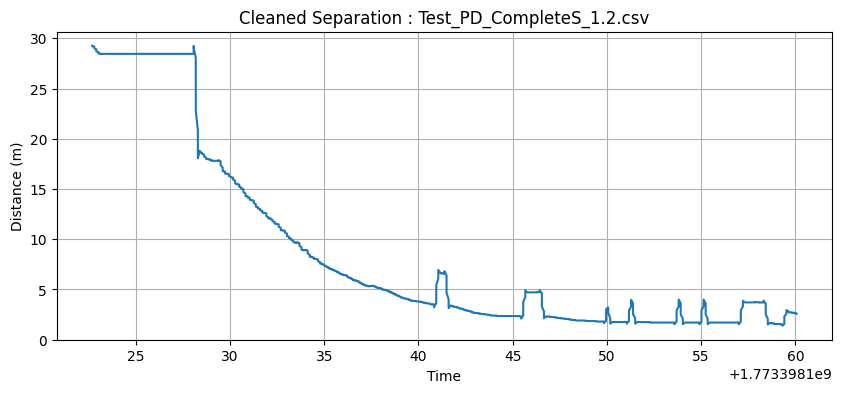

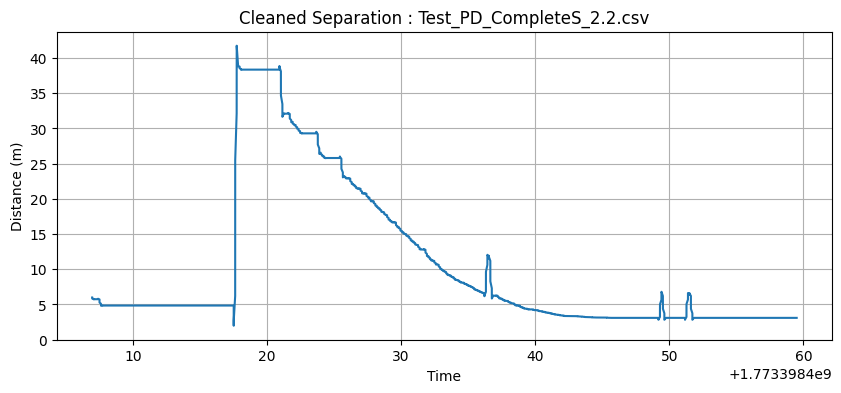

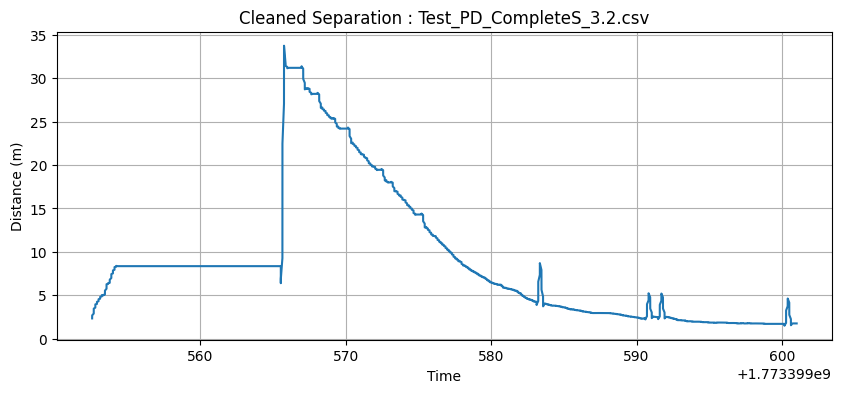

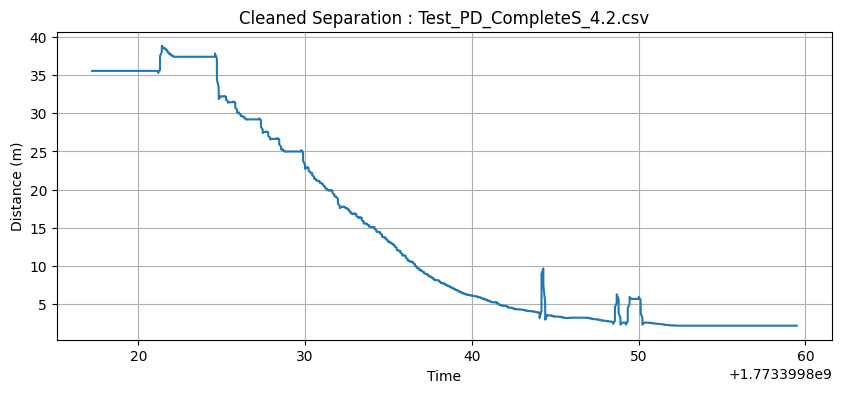

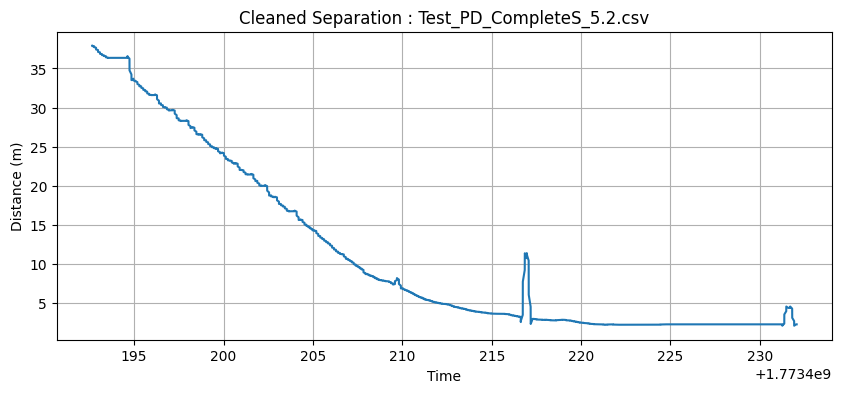

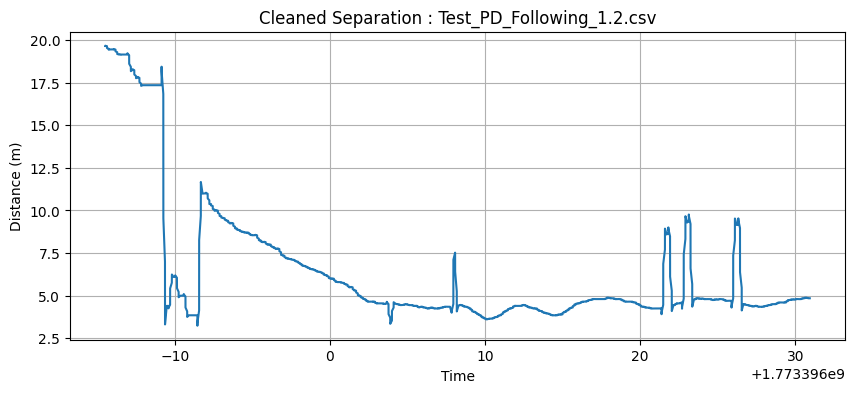

In [11]:
for name, df in cleaned_data.items():

    if "separation" not in df.columns:
        continue

    plt.figure(figsize=(10,4))

    plt.plot(df["ros_time"], df["separation"])

    plt.title(f"Cleaned Separation : {name}")
    plt.xlabel("Time")
    plt.ylabel("Distance (m)")
    plt.grid()

    plt.show()

In [12]:
output_folder = "cleaned_csv"
os.makedirs(output_folder, exist_ok=True)

for name, df in cleaned_data.items():

    df.to_csv(os.path.join(output_folder, name), index=False)

## For 2.2 Data Set

In [44]:
# -------- PATH --------
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_2.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

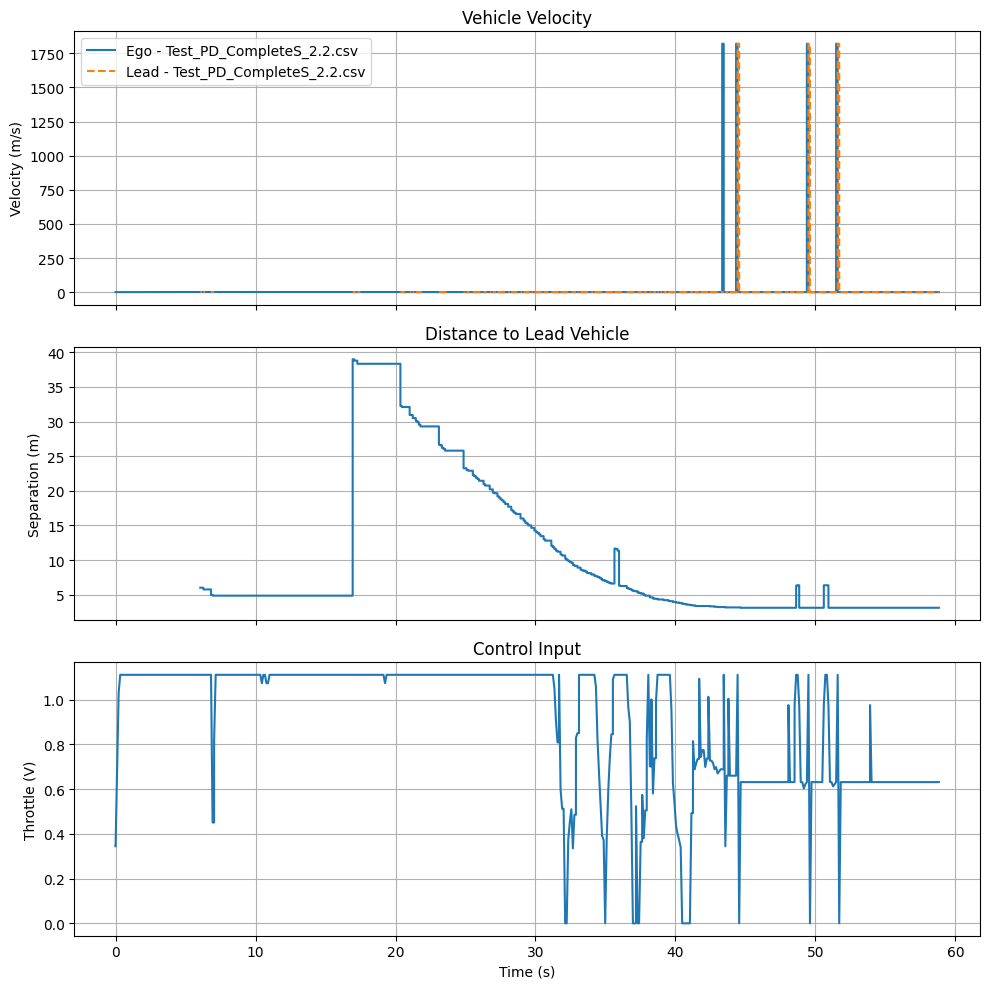

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 3.2 Data set 

In [46]:
# -------- PATH --------
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_3.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

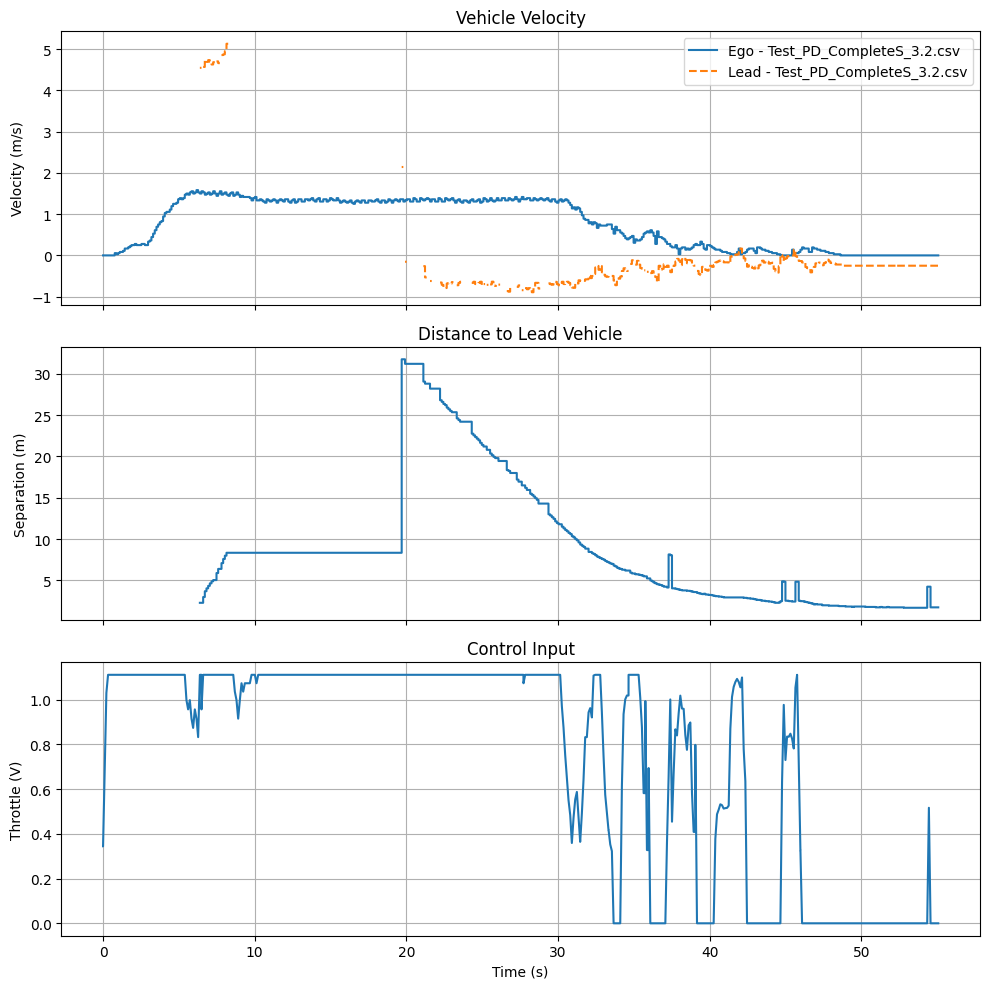

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 4.2 Data set

In [48]:
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_4.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

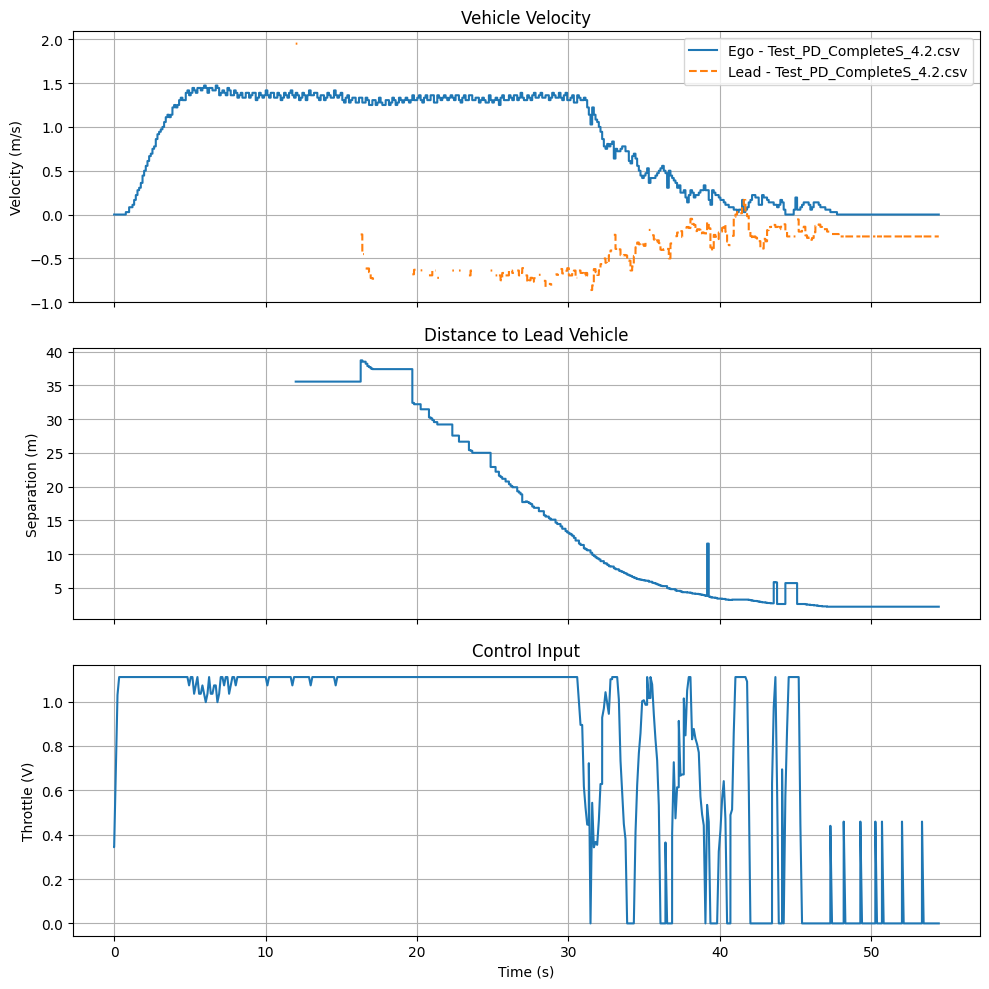

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 5.2 Dataset

In [50]:
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_5.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

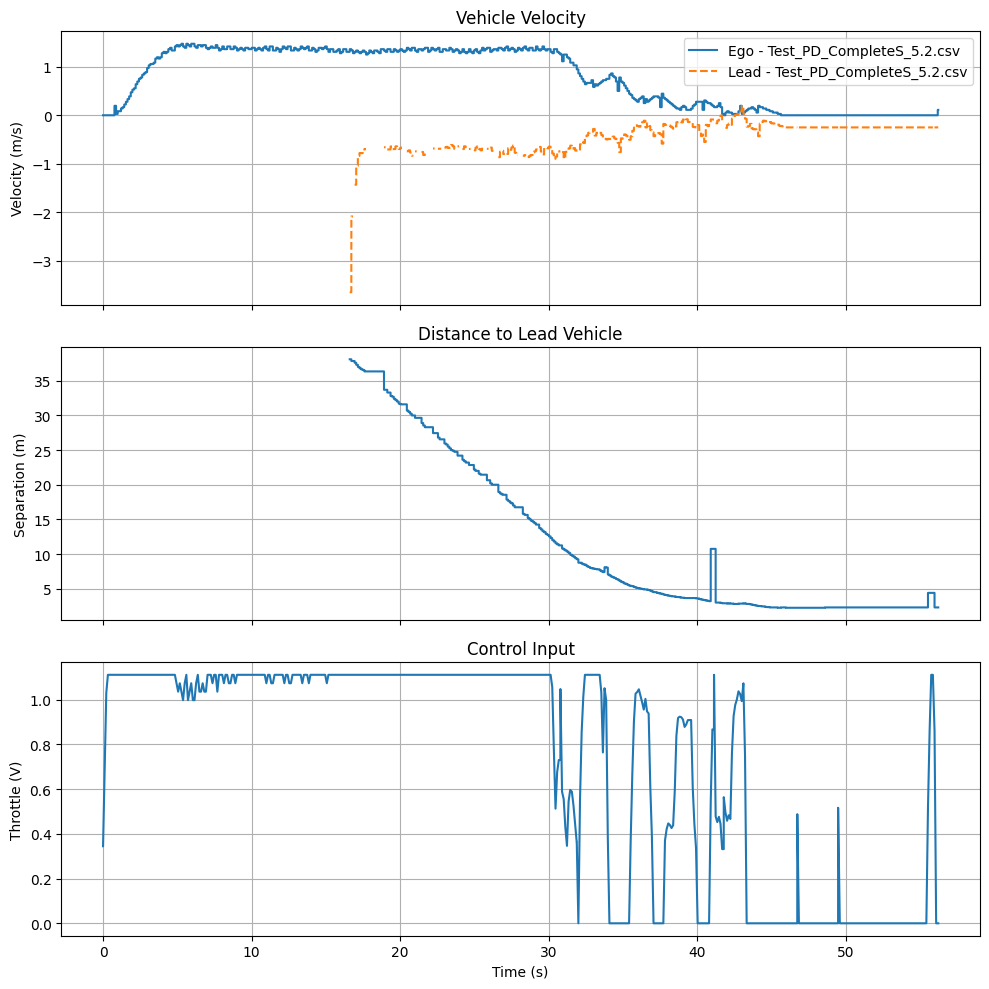

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()